In [1]:
#Q1: Simple Forecast Using Moving Average

import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

data = pd.read_csv(url)

data["Month"] = pd.to_datetime(data["Month"])
data.set_index("Month", inplace=True)

last_12_months = data["Passengers"].tail(12)

forecast = last_12_months.mean()

print("Last 12 Month Average:", forecast)
print("Predicted Next Value:", forecast)

Last 12 Month Average: 476.1666666666667
Predicted Next Value: 476.1666666666667


<Figure size 1200x500 with 0 Axes>

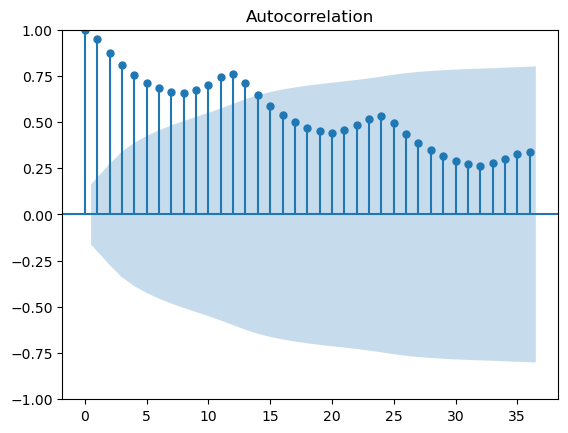

<Figure size 1200x500 with 0 Axes>

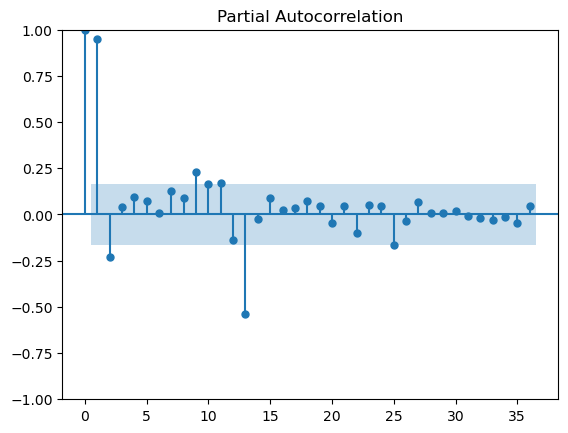

In [2]:
#Q2: Autocorrelation and Partial Autocorrelation

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plot_acf(data["Passengers"], lags=36)
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(data["Passengers"], lags=36, method="ywm")
plt.show()

In [3]:
#Q3: Fit ARIMA Model and Forecast

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    data["Passengers"],
    order=(2, 1, 2)
)

model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

print("Next 12 Months Forecast:")
print(forecast)

D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Next 12 Months Forecast:
1961-01-01    439.854915
1961-02-01    465.296688
1961-03-01    500.666348
1961-04-01    535.971913
1961-05-01    561.689846
1961-06-01    571.313619
1961-07-01    562.973140
1961-08-01    539.730011
1961-09-01    508.528751
1961-10-01    478.147655
1961-11-01    456.747363
1961-12-01    449.696780
Freq: MS, Name: predicted_mean, dtype: float64


D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [4]:
#Q4: Load and Visualize Daily Minimum Temperature

import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

temp_data = pd.read_csv(url)

temp_data["Date"] = pd.to_datetime(temp_data["Date"])

temp_data.set_index("Date", inplace=True)

print(temp_data.head())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


In [5]:
#Q5: Check Seasonality with Monthly Mean

temp_data["Month"] = temp_data.index.month

monthly_mean = temp_data.groupby("Month")["Temp"].mean()

print(monthly_mean)

Month
1     15.030323
2     15.373759
3     14.565484
4     12.088333
5      9.866452
6      7.278333
7      6.692581
8      7.891290
9      8.976333
10    10.309355
11    12.479667
12    13.851948
Name: Temp, dtype: float64
